# Percolation through thick unsaturated zones with the Kinematic-Wave method

This notebook demonstrates `gwtransport.percolation`, an exact front-tracking solver for the
Kinematic-Wave (KW) percolation problem of Olsthoorn (2026, *Stromingen* 32(1)). The KW
approximation drops capillary stress from Richards' equation, leaving the scalar conservation
law

$$\frac{\partial \theta_m}{\partial t} + \frac{\partial K(\theta_m)}{\partial z} = 0,$$

solved exactly with Brooks-Corey or van Genuchten-Mualem conductivity curves, with an optional
time-only scaling of `K` (e.g. for temperature-dependent water viscosity).

**Plotting note.** The model output `q_water_table` is a *bin average* over the output time
edges, so it is drawn as **step plots**. The **exact** breakthrough — continuous, with
rarefactions from their exact self-similar profile and shocks as sharp jumps — is overlaid as a
solid line, reusing `gwtransport.fronttracking.output.identify_outlet_segments`.

**Contents**

1. Soil O05 parameters
2. Step response at multiple depths (exact line + bin-averaged steps)
3. Drying-tail rarefaction breakthrough
4. Time-varying water viscosity via K-scaling


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gwtransport.fronttracking.output import concentration_at_point, identify_outlet_segments
from gwtransport.percolation import root_zone_to_water_table_kinematic_wave

warnings.filterwarnings("ignore", message="compute_bin_averaged_concentration_exact")
plt.rcParams["axes.grid"] = True

## Plot helper

`plot_breakthrough` overlays, for one percolation column:

- the **exact** outlet flux as a continuous line — constant segments drawn flat, rarefaction
  segments sampled from `RarefactionWave.concentration_at_point` (exact self-similar profile),
  shocks appearing as sharp jumps between segments;
- the **bin-averaged** `q_water_table` as a step plot (`plt.stairs`).

For a K-scaling run, the solver's exact curve is the reference-frame `K_ref`; the physical flux
is `f(t)·K_ref(t)`, so the exact line is sampled finely and multiplied by `f(t)` (a constant-
`K_ref` segment becomes time-varying once `f(t)` multiplies it). The returned `q_water_table`
is already physical.


In [2]:
def _f_at(t_days, k_scaling, tedges):
    """Piecewise-constant k_scaling f(t) sampled at t_days (days from tedges[0])."""
    if k_scaling is None:
        return np.ones_like(np.asarray(t_days, dtype=float))
    edges = ((tedges[:-1] - tedges[0]) / pd.Timedelta(days=1)).to_numpy()
    idx = np.clip(np.searchsorted(edges, t_days, side="right") - 1, 0, len(k_scaling) - 1)
    return np.asarray(k_scaling, dtype=float)[idx]


def plot_breakthrough(ax, structure, q_wt, q_wt_tedges, tedges, *, k_scaling=None, color="C0", label="", to_mm=True):
    """Overlay the exact breakthrough (line) and the bin-averaged flux (steps)."""
    state = structure["tracker_state"]
    scale = 1e3 if to_mm else 1.0  # m/day -> mm/day for display
    t_max = float((q_wt_tedges[-1] - q_wt_tedges[0]) / pd.Timedelta(days=1))

    if k_scaling is None:
        # Segment-based exact curve: sharp shocks + exact rarefactions.
        theta_lo = state.theta_at_t(0.0)
        theta_hi = state.theta_at_t(t_max)
        segments = identify_outlet_segments(theta_lo, theta_hi, state.v_outlet, state.waves, state.sorption)
        first = True
        for seg in segments:
            t0 = state.t_at_theta(seg["theta_start"])
            t1 = state.t_at_theta(seg["theta_end"])
            if seg["type"] == "constant":
                ax.plot(
                    [t0, t1],
                    [seg["concentration"] * scale] * 2,
                    color=color,
                    lw=1.6,
                    label=f"{label} exact" if first else None,
                )
            else:
                raref = seg["wave"]
                tt = np.linspace(t0, t1, 80)
                cc = np.array([
                    raref.concentration_at_point(state.v_outlet, state.theta_at_t(float(t))) or 0.0 for t in tt
                ])
                ax.plot(tt, cc * scale, color=color, lw=1.6, label=f"{label} exact" if first else None)
            first = False
    else:
        # K-scaling: fine-sample K_ref and multiply by f(t).
        tt = np.linspace(0.0, t_max, 1500)
        kref = np.array([
            concentration_at_point(state.v_outlet, state.theta_at_t(float(t)), state.waves, state.sorption) for t in tt
        ])
        ax.plot(tt, kref * _f_at(tt, k_scaling, tedges) * scale, color=color, lw=1.6, label=f"{label} exact")

    edges = ((q_wt_tedges - q_wt_tedges[0]) / pd.Timedelta(days=1)).to_numpy()
    ax.stairs(q_wt * scale, edges, color=color, ls="--", lw=1.2, alpha=0.8, label=f"{label} bin avg")

## 1. Soil O05 (coarse sand)

`K_s = 17.4 cm/d`, `θ_r = 0.01`, `θ_s = 0.337`. Brooks-Corey `λ = 0.25` (a = 11); van
Genuchten `n = 2.28`, `L = 0.5` (Heinen et al. 2020 Staringreeks).

In [3]:
THETA_R, THETA_S, K_S = 0.01, 0.337, 0.174  # m/day
BC_LAMBDA, VG_N = 0.25, 2.28

## 2. Step response at multiple depths

Constant root-zone flux `q = 2 mm/d`. The exact breakthrough is a sharp wetting-front jump at
arrival; the bin-averaged output (10-day bins) ramps across the bin that contains the arrival.
Deeper columns arrive later.

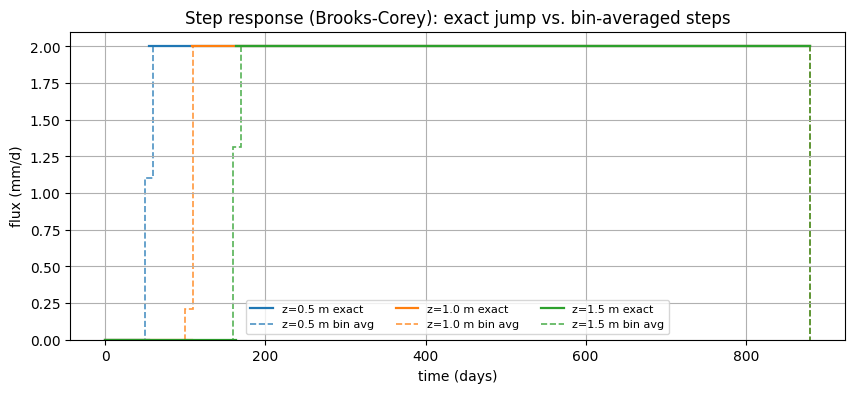

In [4]:
tedges = pd.date_range("2000-01-01", "2002-06-01", freq="D")
n = len(tedges) - 1
q0 = 0.002
q_root = np.full(n, q0)
out_tedges = pd.date_range("2000-01-01", "2002-06-01", freq="10D")  # coarse -> visible steps

fig, ax = plt.subplots(figsize=(10, 4))
for j, z in enumerate([0.5, 1.0, 1.5]):
    q_wt, structures = root_zone_to_water_table_kinematic_wave(
        q_root_zone=q_root,
        tedges=tedges,
        q_water_table_tedges=out_tedges,
        cumulative_pore_volumes_outlet=np.array([THETA_S * z]),
        theta_r=THETA_R,
        theta_s=THETA_S,
        k_s=K_S,
        brooks_corey_lambda=BC_LAMBDA,
    )
    plot_breakthrough(ax, structures[0], q_wt, out_tedges, tedges, color=f"C{j}", label=f"z={z} m")
ax.set_xlabel("time (days)")
ax.set_ylabel("flux (mm/d)")
ax.set_title("Step response (Brooks-Corey): exact jump vs. bin-averaged steps")
ax.legend(ncol=3, fontsize=8)
plt.show()

## 3. Drying-tail rarefaction breakthrough

Wetting (`q = 3 mm/d`) for 40 days then drying to `q = 0.5 mm/d`. The outlet first sees the
sharp wetting front, then a smooth **rarefaction** as the drying tail arrives. The exact line
renders the self-similar fan; the bin-averaged steps approximate it.

Reached max_iterations=10000


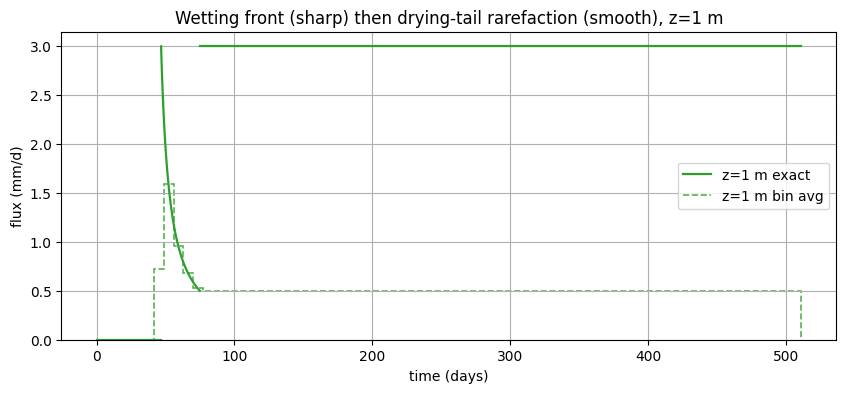

In [5]:
tedges2 = pd.date_range("2000-01-01", "2001-06-01", freq="D")
n2 = len(tedges2) - 1
q_root2 = np.full(n2, 0.0005)
q_root2[:40] = 0.003
out_tedges2 = pd.date_range("2000-01-01", "2001-06-01", freq="7D")

q_wt2, structures2 = root_zone_to_water_table_kinematic_wave(
    q_root_zone=q_root2,
    tedges=tedges2,
    q_water_table_tedges=out_tedges2,
    cumulative_pore_volumes_outlet=np.array([THETA_S * 1.0]),
    theta_r=THETA_R,
    theta_s=THETA_S,
    k_s=K_S,
    brooks_corey_lambda=BC_LAMBDA,
)
fig, ax = plt.subplots(figsize=(10, 4))
plot_breakthrough(ax, structures2[0], q_wt2, out_tedges2, tedges2, color="C2", label="z=1 m")
ax.set_xlabel("time (days)")
ax.set_ylabel("flux (mm/d)")
ax.set_title("Wetting front (sharp) then drying-tail rarefaction (smooth), z=1 m")
ax.legend()
plt.show()

## 4. Time-varying water viscosity via K-scaling

`K ∝ 1/μ(T)`; a seasonal 10 ± 5 °C swing gives ~30-50% variation in effective `K_s`. The
`k_scaling = μ_ref/μ(T(t))` argument absorbs this exactly (cumulative-flow trick). The exact
line is `f(t)·K_ref(t)`; the bin-averaged output is already physical.

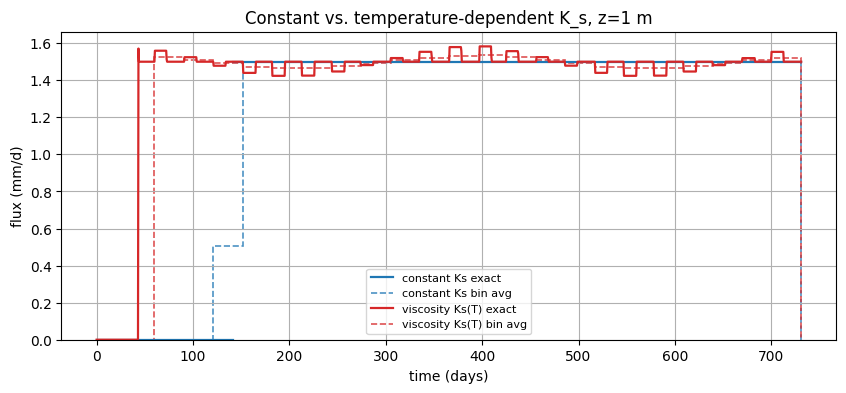

In [6]:
# Monthly resolution: under K-scaling cin_solver = q_root/f(t) varies with f, so a daily f
# would create ~730 inlet waves. Monthly keeps the event count modest; the seasonal
# smoothing is identical at any resolution.
tedges3 = pd.date_range("2000-01-01", "2002-01-01", freq="MS")
n3 = len(tedges3) - 1
days3 = ((tedges3[:-1] - tedges3[0]) / pd.Timedelta(days=1)).to_numpy()
q_root3 = np.full(n3, 0.0015)
T = 10.0 + 5.0 * np.sin(2 * np.pi * days3 / 365.25)
mu = 1.31 - 0.027 * (T - 10.0)  # mPa·s, linear around 10 °C
k_scaling = 1.31 / mu

q_wt_const, struct_const = root_zone_to_water_table_kinematic_wave(
    q_root_zone=q_root3,
    tedges=tedges3,
    q_water_table_tedges=tedges3,
    cumulative_pore_volumes_outlet=np.array([THETA_S * 1.0]),
    theta_r=THETA_R,
    theta_s=THETA_S,
    k_s=K_S,
    brooks_corey_lambda=BC_LAMBDA,
)
q_wt_visc, struct_visc = root_zone_to_water_table_kinematic_wave(
    q_root_zone=q_root3,
    tedges=tedges3,
    q_water_table_tedges=tedges3,
    cumulative_pore_volumes_outlet=np.array([THETA_S * 1.0]),
    theta_r=THETA_R,
    theta_s=THETA_S,
    k_s=K_S,
    brooks_corey_lambda=BC_LAMBDA,
    k_scaling=k_scaling,
)
fig, ax = plt.subplots(figsize=(10, 4))
plot_breakthrough(ax, struct_const[0], q_wt_const, tedges3, tedges3, color="C0", label="constant Ks")
plot_breakthrough(
    ax, struct_visc[0], q_wt_visc, tedges3, tedges3, k_scaling=k_scaling, color="C3", label="viscosity Ks(T)"
)
ax.set_xlabel("time (days)")
ax.set_ylabel("flux (mm/d)")
ax.set_title("Constant vs. temperature-dependent K_s, z=1 m")
ax.legend(fontsize=8)
plt.show()

## References

- Olsthoorn, T.N. (2026). Percolation through thick unsaturated zones — Munsflow vs. the Kinematic Wave. *Stromingen* 32(1).
- Heinen, M., Bakker, G., Wösten, J.M.H. (2020). *Waterretentie en Doorlatendheidskarakteristieken … Staringreeks. Update 2018.* Wageningen Environmental Research, Report 2978.
- Charbeneau, R.J. (2000). *Groundwater Hydraulics and Pollutant Transport.* Prentice Hall.
